<a href="https://colab.research.google.com/github/deepan98raj-dotcom/My_Project/blob/main/Sentiment_text_generation_hugging_face.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score, accuracy_score, classification_report
from transformers import pipeline
import torch

In [20]:
classifier = pipeline('sentiment-analysis')

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [21]:
classifier('this is a great movie')

[{'label': 'POSITIVE', 'score': 0.9998798370361328}]

In [22]:
classifier([
    "I did not understood any of it"
])

[{'label': 'NEGATIVE', 'score': 0.9996486902236938}]

In [23]:
airline_tweets = pd.read_csv('Tweets.csv')
airline_tweets.head(5)

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [24]:
df= airline_tweets[['airline_sentiment','text']]
df.head()

,airline_sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...


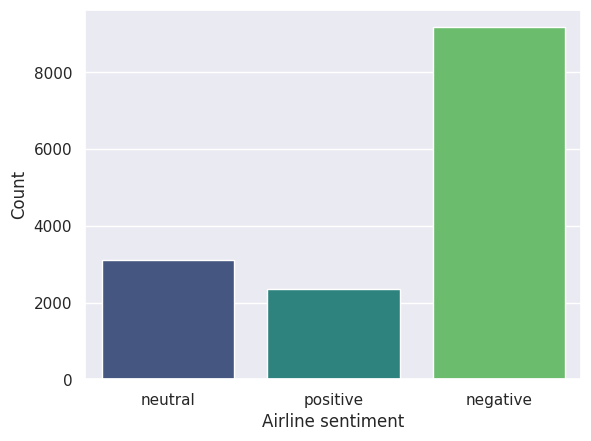

In [25]:
sns.countplot(df, x='airline_sentiment',palette='viridis')
plt.xlabel('Airline sentiment')
plt.ylabel('Count')
plt.show()

In [26]:
df = df[df['airline_sentiment'] != 'neutral']

In [27]:
df['target'] = df['airline_sentiment'].map({'positive':1, 'negative': 0})

In [28]:
print('number of rows:',df.shape[0])

number of rows: 11541


In [29]:
texts = df['text'].tolist()
predictions = classifier(texts)
predictions[:5]

[{'label': 'POSITIVE', 'score': 0.6070846319198608},
 {'label': 'NEGATIVE', 'score': 0.9973449110984802},
 {'label': 'NEGATIVE', 'score': 0.9995823502540588},
 {'label': 'NEGATIVE', 'score': 0.9854250550270081},
 {'label': 'POSITIVE', 'score': 0.9553211331367493}]

In [30]:
probs = [pred['score'] if pred['label'].startswith('p') else 1 - pred['score'] for pred in predictions]

In [31]:
preds = np.array([1 if pred['label'].startswith('p') else 0 for pred in predictions])

In [32]:
print(f'Accuracy: {round(np.mean(df['target']==preds)*100,2)}%')

Accuracy: 79.53%


In [33]:
cm = confusion_matrix(df['target'], preds, normalize = 'true')

In [34]:
def plot_confusion_matrix(confusion_matrix, labels):

  plt.figure(figsize=(8,6))
  sns.set(font_scale=1.6)
  sns.heatmap(confusion_matrix, annot=True, fmt='g', cmap='Blues', xticklabels=labels, yticklabels=labels)
  plt.title('Confusion Matrix')
  plt.xlabel('Predicted Class')
  plt.ylabel('True Class')
  plt.show()


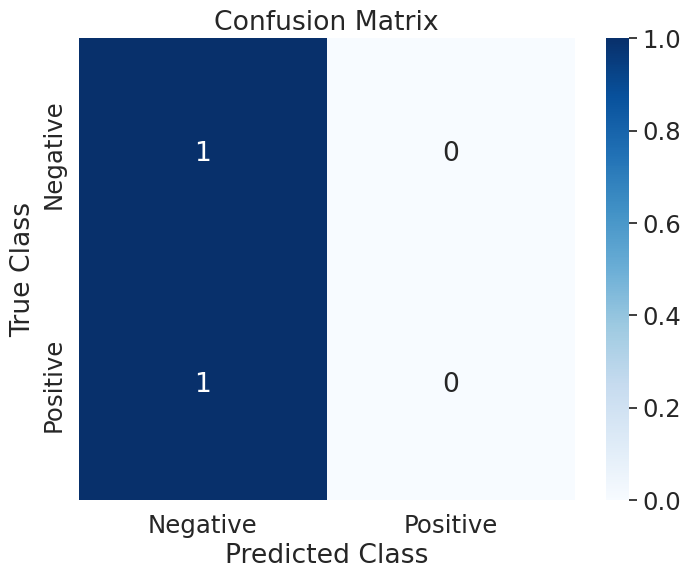

In [35]:
plot_confusion_matrix(cm, ['Negative', 'Positive'])

In [36]:
print(f'roc auc score : {roc_auc_score(df['target'],probs)}')

roc auc score : 0.42248776190870974


In [37]:
import pandas as pd

poems = pd.read_csv('/content/robert_frost.csv')
poems.head(5)

,Name,Content,Collection,Year of Publication
0,NaN,NaN,NaN,NaN
1,Stopping by Woods on a Snowy Evening,Whose woods these are I think I know. \nHis ...,New Hampshire,1923.0
2,Fire and Ice,"Some say the world will end in fire,\nSome say...",New Hampshire,1923.0
3,The Aim was Song,Before man came to blow it right\nThe wind onc...,New Hampshire,1923.0
4,The Need of Being Versed in Country Things,The house had gone to bring again\nTo the midn...,New Hampshire,1923.0


In [38]:
content = poems['Content'].dropna().tolist()

In [39]:
lines = []
for poem in content:
  for line in poem.split('\n'):
    lines.append(line.rstrip())

In [40]:
lines = [line for line in lines if len(line) > 0]
lines[:5]

['Whose woods these are I think I know.',
 'His house is in the village though;',
 'He will not see me stopping here',
 'To watch his woods fill up with snow.',
 'My little horse must think it queer']

In [41]:
from transformers import pipeline

gen = pipeline('text-generation')

[transformers] No model was supplied, defaulted to HuggingFaceTB/SmolLM3-3B and revision a07cc9a.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/326 [00:00<?, ?it/s]

In [42]:
lines[0]

'Whose woods these are I think I know.'

In [43]:
import textwrap
def wrap(x):
  return textwrap.fill(x, replace_whitespace=False,fix_sentence_endings=True)

In [ ]:
prompt = "transformers have a wide variety of applications in nlp"
out= gen(prompt, max_length = 100)
print(wrap(out[0]['generated_text']))

[transformers] Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
